## **_Sample Modeling V1.2_** (for Reinforcement Learning)

* 이 페이지는 "Drying Oven"의 가상 센서 데이터를 이용하여 PPO 모델을 교육하고 예측하는 예제를 구현합니다.
* PPO는 기본적으로 Linear 모델을 지원합니다.
* pip install numpy pandas tensor ipykernel torch scikit-learn gymnasium stable_baselines3

In [119]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------
import os
import sys
from pathlib import Path
from datetime import datetime

csv_file_pathname = lambda: f".{os.sep}data{os.sep}drying_oven_sensor_v1.1_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
model_path_name = lambda: f".{os.sep}model{os.sep}ppo_dryer_control_v1.1_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
global_num_samples = 50000
parent_dir = os.path.dirname(os.getcwd())
project_home_dir = str(Path.cwd().parent.parent)
venv_name = "samplemodelingv1.1"

reward_gen_fn="lib/reward/dryer_oven/gen_reward_v1.py"
reward_gen_fn = reward_gen_fn.replace("/", os.sep)
reward_gen_fn_pythonfile = project_home_dir + os.sep + reward_gen_fn
simulation_cls_pathname = "lib/simulate/dryer_oven_simulation.py"
simulation_cls_pathname = simulation_cls_pathname.replace("/", os.sep)
simulation_cls_pathname = project_home_dir + os.sep + simulation_cls_pathname


In [120]:
# ----------------------------------------------------
# 개발 환경 초기화
# 한 번만 호출하여 주십시요.


# 1.1 set pythonpath to import from parent directory
def _init_environ():
    python_path = os.environ.get("PYTHONPATH")
    if python_path is None:
        python_path = ""
    sys.path.append(parent_dir)
    sys.path.append(project_home_dir)
    python_lib_path = [
        f'{project_home_dir}{os.sep}{venv_name}{os.sep}{"Lib" if sys.platform == "win32" else "lib"}{os.sep}site-packages',
        project_home_dir,
        python_path
    ]
    os.environ["PYTHONPATH"] = ";".join(python_lib_path)

    os.environ["CLEARML_WEB_HOST"] = "http://172.16.8.168:8080/"
    os.environ["CLEARML_API_HOST"] = "http://172.16.8.168:8008/"
    os.environ["CLEARML_FILES_HOST"] = "http://172.16.8.168:8081"
    os.environ["CLEARML_API_ACCESS_KEY"] = "SIJ8V8YP9PL25YEAVAWGP9NV11TMOQ"
    os.environ["CLEARML_API_SECRET_KEY"] = "6x_MEHvgrUv9-TFFDrE9BE7vb3JYOXDWq4kQtqbd58nQ5pqHEGMt6qQXxF7_HCyzq7E"

_init_environ()


In [121]:
!echo $PYTHONPATH
from lib.simulate.genetate_data import generate_data_v1

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25
drop_envs = [(0.4, 100, 30), (0.5, 200, 40)]
spike_envs = [(0.6, 300, 30), (0.7, 200, 40), (0.8, 200, 70)]
verbose = 0


stored_data_file_pathname = generate_data_v1(drop_envs=drop_envs,
                                             spike_envs=spike_envs,
                                             csv_file_pathname=csv_file_pathname(),
                                             num_samples=global_num_samples,
                                             target_temp=target_temp,
                                             initial_temp=initial_temp,
                                             verbose=verbose)
print(f"Data stored in: {stored_data_file_pathname}")

/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/samplemodelingv1.1/lib/site-packages;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/samplemodelingv1.1/lib/site-packages;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks;
Start to generate sample data. [2026-03-30 17:17:39.086046]
End to generate sample data. [2026-03-30 17:17:39.213977]
Data stored in: ./data/drying_oven_sensor_v1.1_20260330_171739.csv


#### Step 2 Env 생성

In [137]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from lib.module import _load_class_module as load_class
from lib.module import load_function


class DryerEnv(gym.Env):
    """
    RecurrentPPO 학습을 위한 건조기 온도 제어 환경
    목표: 팬 RPM을 조절하여 내부 온도를 80도로 유지하기
    """
    init_sim_data = [{
            "timestamp": 0.0,
            "inner_temp": 79.5,  # 실측 온도
            "error": -0.5,       # 실측 온도 - 목표 온도
            "humidity": 45.2,    # 실측 습도
            "weight": 4.65,      # 실측 무게
            "outer_temp": 22.1,
            "pressure": 1012.8,
            "fan_rpm": 1550.0,
            "user_action": 0
        },
        {
            "timestamp": 0.0,
            "inner_temp": 25,  # 실측 온도
            "error": -55,      # 실측 온도 - 목표 온도
            "humidity": 80,    # 실측 습도
            "weight": 5.0,     # 실측 무게
            "outer_temp": 22.0,
            "pressure": 1013.0,
            "fan_rpm": 1500.0,
            "user_action": 2
        }
    ]

    OVER_TEMP_LIMIT=15.0

    def __init__(self, reward_gen_fn_pathname=None, is_simulatation=True, simulation_cls_pahname=None, debug=False):
        """
        ; params reward_gen_fn: str, 보상 계산을 위한 사용자 정의 함수 (선택적)
        ' params is_simulation: boolean, 시뮬레이션 모드 여부 (True: 시뮬레이터, False: 실제 환경)
        """
        super().__init__()

        # 1. Action Space: [0: DOWN, 1: KEEP, 2: UP]
        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32
        )        
        self.is_simulation = is_simulatation
        self._debug = debug
        self.target_temp = 80.0
        self.max_steps = 10000
        self.state = []
        self.terminated = False
        self.current_step = 0
        self.prev_inner_temp = None  # 이전 온도 저장용
        self.truncated = False
        self.simulation_cls_pahname: str = simulation_cls_pahname
        self.simulation_cls = load_class(self.simulation_cls_pahname)(debug=False) if self.simulation_cls_pahname else None
        self.reward_gen_fn_pathname: str = reward_gen_fn_pathname
        self.reward_gen_fn = load_function(self.reward_gen_fn_pathname, "generate_reward") if self.reward_gen_fn_pathname else None
        self.reset()

    def _send_action_to_dryer(self, action):
        """
        건조기 하드웨어로 제어 신호(RPM 조절)를 전송하는 함수
        실제 환경에서는 MQTT publish나 API POST 요청이 들어갑니다.
        """
        action_map = {0: "DOWN", 1: "KEEP", 2: "UP"}
        command = action_map[action]
        # 예시: requests.post(f"http://dryer-ip/control", json={"action": command})
        # print(f"[Hardware] Sent command: {command} to {self.device_id}")
        pass

    def _get_data_from_dryer(self, action):
        """
        건조기 센서로부터 실측 데이터를 읽어오는 함수
        실제 환경에서는 센서 API 호출이나 DB 조회가 들어갑니다.
        """
        # 예시: response = requests.get(f"http://dryer-ip/sensors").json()
        # 가상의 실측 데이터 구조 (API 응답 가정)
        if self.is_simulation:
            if len(self.state) == 8 and self.simulation_cls is not None:
                real_measured_data = self.simulation_cls.step(action = action, state = self.state)
            else:
                real_measured_data = DryerEnv.init_sim_data[1]
        else:
            ## 실제 상황에서는 건조기에서 데이터를 가져와야 합니다. 
            real_measured_data = DryerEnv.init_sim_data[0]
            
        return np.array([real_measured_data["timestamp"],
                         real_measured_data["inner_temp"],
                         real_measured_data["error"],
                         real_measured_data["humidity"],
                         real_measured_data["weight"],
                         real_measured_data["outer_temp"],
                         real_measured_data["pressure"],
                         real_measured_data["fan_rpm"]],
                         dtype=np.float32)

    def reset(self, seed=None, options=None, is_gen_data=True):
        super().reset(seed=seed)
        self.current_step = 0
        if self.terminated:
            pre_user_action = 0
        else:
            pre_user_action = 1
        if self._debug:
            print(f'DryerEnv.rest()')
        if is_gen_data:
            self.state = self._get_data_from_dryer(action=pre_user_action)
        else:
            self.state = None
        self.terminated = False
        self.truncated = False
        self.prev_inner_temp = None
        return self.state, {}
    
    @staticmethod
    def _unpack_nptype(np_value):
        import numpy
        if isinstance(np_value, (numpy.float32, numpy.float64, np.float32, np.float64,
                                 numpy.int32, numpy.int64, np.int32, np.int64,
                                 numpy.ndarray, np.ndarray)):
            return np_value.item()
        return np_value

    def _generate_reward_default(self, current_temp, action):
        """
        # 보상(Reward)
        ; params inner_temp;
        ; return reward, terminated, truncated
        """
        diff = current_temp - self.target_temp
        reward = -abs(np.diff)
    
        # 올바른 대응에 보너스
        if np.diff < -1.0 and action == 0: reward += 20.0 # 추울 때 RPM 낮추면 칭찬
        if diff > 1.0 and action == 2:  reward += 20.0 # 더울 때 RPM 높이면 칭찬
        # 목표 온도 근처(±2도)에 도달 시 추가 보상
        if abs(diff) <= 1.0:
            reward += 30.0

        # if diff > 1.0: # 온도가 높음
        #     reward += (20.0 if action == 2 else -30.0) # UP이면 상, DOWN/KEEP이면 큰 벌

        # 4. 종료 조건
        terminated = self.current_step >= self.max_steps
        truncated = False
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        max_allow_temp = DryerEnv.OVER_TEMP_LIMIT + self.target_temp
        min_allow_temp = DryerEnv.OVER_TEMP_LIMIT
        if current_temp > max_allow_temp or current_temp < min_allow_temp:
            terminated = True
            reward -= 100
        return reward, terminated, truncated

    def _generate_reward(self, inner_temp, action):
        if self.reward_gen_fn:
            return self.reward_gen_fn(inner_temp=inner_temp,
                                      action=action,
                                      prev_inner_temp=self.prev_inner_temp,
                                      target_temp=self.target_temp,
                                      temp_limit_depth=DryerEnv.OVER_TEMP_LIMIT)
        if self._debug > 0:
            print("No reward generation function provided.")
        return self._generate_reward_default(current_temp=inner_temp, action=action)
    
    def _check_terminate(self, inner_temp, reward, max_steps, current_step):
        """
        4. 종료 조건
        """
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        terminated = False
        if inner_temp > 90 or inner_temp < 15:
            terminated = True
            reward -= 100
    
        if current_step > max_steps:
            terminated = True
        
        truncated = False
        return reward, terminated, truncated
    
    def _load_observation(self, action: int = 1, current_step: int = 0):
        # 실제 환경에서는 센서 데이터를 읽어와서 self.state를 업데이트해야 합니다.
        # 예시: self.state = self._get_data_from_dryer(action=self.pre_user_action)
        return self._get_data_from_dryer(action=action)

    def step(self, action):
        self.current_step += 1

        action = DryerEnv._unpack_nptype(action)
        # print(f'self.state #-1 = {self.state}, {action}[{type(action)}]')        
        self._send_action_to_dryer(action)

        if self.current_step > self.max_steps:
            self.current_step = self.max_steps # 인덱스 초과 방지

        # print(f'self.state #0 = {self.state}')
        self.state = self._load_observation(action=action,current_step=self.current_step)

        for i in range(len(self.state)):
            self.state[i] = DryerEnv._unpack_nptype(self.state[i])

        inner_temp_pos = 1
        inner_temp = self.state[inner_temp_pos]
        # 5. 보상 계산
        reward = self._generate_reward(inner_temp=inner_temp, action=action)

        # 4. 종료 조건
        reward, self.terminated, self.truncated = self._check_terminate(inner_temp=inner_temp,
                                                                        reward=reward,
                                                                        max_steps=self.max_steps,
                                                                        current_step=self.current_step)
        # 5. 다음 스텝을 위해 현재 온도와 action을 저장
        self.pre_user_action = 0 if self.terminated else action
        self.prev_inner_temp = inner_temp
        return self.state, reward, self.terminated, self.truncated, {}


# 환경 테스트
if __name__ == "__main__":
    env = DryerEnv(reward_gen_fn_pathname=reward_gen_fn_pythonfile,
                   is_simulatation=True,
                   simulation_cls_pahname=simulation_cls_pathname)
    obs, _ = env.reset()
    print(f"Initial Obs: {obs}")
    
    # 랜덤 액션 테스트
    for i in range(10):
        action = env.action_space.sample()
        in_temp = obs[1]
        obs, reward, done, _, _ = env.step(action)
        print(f"[{i:03d}] Action: {action}, In Temp: {in_temp:.2f}, Out Temp: {obs[1]:.2f}, Reward: {reward:.2f}")

module_path_name = /home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py
ModuleSpec(name='classname', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7731b02f0620>, origin='/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py') <class '_frozen_importlib.ModuleSpec'>
Initial Obs: [   0.        32.24167  -47.75833    0.        20.        22.
 1013.      1500.     ]
[000] Action: 2, In Temp: 32.24, Out Temp: 37.64, Reward: -1843.97
[001] Action: 0, In Temp: 37.64, Out Temp: 41.69, Reward: -1417.65
[002] Action: 2, In Temp: 41.69, Out Temp: 44.70, Reward: -1296.28
[003] Action: 1, In Temp: 44.70, Out Temp: 46.94, Reward: -1142.83
[004] Action: 0, In Temp: 46.94, Out Temp: 48.64, Reward: -933.62
[005] Action: 0, In Temp: 48.64, Out Temp: 49.92, Reward: -854.66
[006] Action: 1, In Temp: 49.92, Out Temp: 50.88, Reward: -897.77
[007] Action: 1, In Temp: 50.88, Out Temp: 51.60, Reward: -856.42
[00

#### Step 3 모방 학습(Behavioral Cloning)으로 PPO 초기화하기

##### Step 3.1 가상 데이터를 로딩하는 Env 작성

In [138]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np

class CSVDataDryerEnv(DryerEnv):
    def __init__(self, csv_file, reward_gen_fn_pathname=None):
        # 데이터 로드
        self.df = pd.read_csv(csv_file)
        self.max_steps = len(self.df) - 1
        # super(CSVDataDryerEnv, self).__init__(reward_gen_fn_pathname=reward_gen_fn_pathname,
        #                                       is_simulatation=False)
        super().__init__(reward_gen_fn_pathname=reward_gen_fn_pathname, is_simulatation=False)

    def _load_observation(self, action: int = 1, current_step: int = 0):
        # CSV의 특정 행에서 데이터를 가져와서 state로 반환
        row = self.df.iloc[current_step]
        return np.array([
            row['timestamp'],
            row['inner_temp'],
            row['inner_temp'] - self.target_temp,
            row['humidity'],
            row['weight'],
            row['outer_temp'],
            row['pressure'],
            row['fan_rpm']
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed, is_gen_data=False)
        self.state = self._load_observation(action=1, current_step=self.current_step)
        return self.state, {}


##### 3.2 모방 학습 하기


In [139]:
import gymnasium as gym
from stable_baselines3 import PPO
# from lib.callback.ppo_event_callback import PPOEventCallback
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor


cb_verbose = 1


def train_dryer_model_from_csv(model_path_name,
                               n_steps=128,
                               csv_path: str='dryer_virtual_data.csv',
                               reward_gen_fn_pathname=None,
                               learn_repeat_cnt: int=5):
    # 1. CSV 기반 환경 생성
    base_env = CSVDataDryerEnv(csv_file=csv_path,
                               reward_gen_fn_pathname=reward_gen_fn_pathname)
    env = DummyVecEnv([lambda: base_env])
    # callback = PPOEventCallback(check_freq=20, cb_verbose=cb_verbose)

    # 2. 모델 설정 (Linear 기반 PPO)
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        n_steps=n_steps,
        batch_size=64,
        ent_coef=0.1,
        learning_rate=1e-5
    )

    # 3. 학습 시작
    # CSV 데이터의 크기에 맞춰 학습 횟수를 조절하세요.
    print(f"{csv_path} 데이터를 기반으로 학습을 시작합니다...")
    model.learn(total_timesteps=len(base_env.df) * learn_repeat_cnt,  # 데이터를 5번 반복 학습
                )

    trained_model_path_name = model_path_name()
    # 4. 저장
    model.save(trained_model_path_name)
    print("학습 및 모델 저장 완료")
    
    return model, trained_model_path_name

n_steps = 512
learn_repeat_cnt = 1
# 학습 실행
# checkpoint_callback = CheckpointCallback(save_freq=5000, save_path='./logs/', name_prefix='dryer_model')
# trained_model = train_dryer_model(model_path_name=model_path_name, total_timesteps=10000, n_epochs=1)
print(f"Trained will start. [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")

trained_model, trained_model_path_name = train_dryer_model_from_csv(model_path_name=model_path_name,
                                                                    n_steps=n_steps,
                                                                    csv_path=stored_data_file_pathname,
                                                                    reward_gen_fn_pathname=reward_gen_fn_pythonfile,
                                                                    learn_repeat_cnt=learn_repeat_cnt)
print(f"Trained model saved at: {trained_model_path_name}")


Trained will start. [2026-03-30 17:54:01]
./data/drying_oven_sensor_v1.1_20260330_171739.csv 데이터를 기반으로 학습을 시작합니다...
학습 및 모델 저장 완료
Trained model saved at: ./model/ppo_dryer_control_v1.1_20260330_175440.pth


##### 4. Test

Testing model ./model/ppo_dryer_control_v1.1_20260330_175440.pth for 200 steps...
module_path_name = /home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py
ModuleSpec(name='classname', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7731b0130e00>, origin='/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py') <class '_frozen_importlib.ModuleSpec'>
heater_input=8.0, q_cooling=0.7583292722702026, q_evaporation=0.0
heater_input=8.0, q_cooling=2.5888524055480957, q_evaporation=0.0
heater_input=8.0, q_cooling=3.956662893295288, q_evaporation=0.0
heater_input=8.0, q_cooling=4.97872257232666, q_evaporation=0.0
heater_input=8.0, q_cooling=5.742430686950684, q_evaporation=0.0
heater_input=8.0, q_cooling=6.3130903244018555, q_evaporation=0.0
heater_input=8.0, q_cooling=6.739501476287842, q_evaporation=0.0
heater_input=8.0, q_cooling=7.0581254959106445, q_evaporation=0.0
heater_input=8.0, q_cooling=7

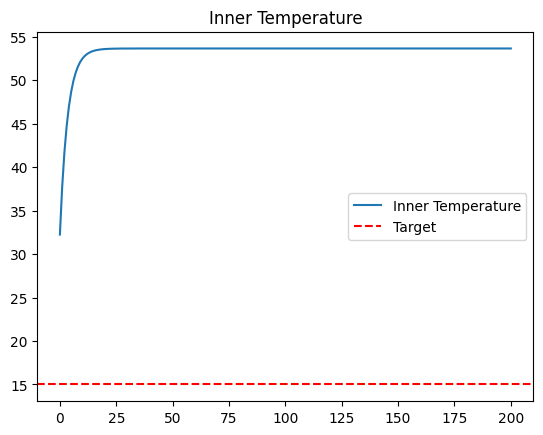

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
# from lib.callback.ppo_event_callback import PPOEventCallback
from stable_baselines3.common.vec_env import DummyVecEnv

inner_temp_history = []
action_history = []
reward_history = []
repeat_cnt = 200
learn_timesteps = -1
# trained_model_path_name ="./model/ppo_dryer_control_v1.1_20260329_231930.pth"  # 방금 저장한 모델 경로 사용

def test_model(model_path_name,
               repeat_cnt=100,
               reward_gen_fn_pathname=None,
               learn_timesteps=1,
               is_simulatation=True,
               simulation_cls_pahname=None):
    # 저장된 모델 로드 및 테스트

    # 1. 원본 환경 생성
    base_env = DryerEnv(reward_gen_fn_pathname=reward_gen_fn_pathname,
                        is_simulatation=is_simulatation,
                        simulation_cls_pahname=simulation_cls_pahname
                        )
    env = DummyVecEnv([lambda: base_env])
    model = PPO.load(model_path_name)
    # 2. Monitor 래핑 (표준 규격 및 로그 기록)
    model.env = env
    obs = model.env.reset()

    in_obs = obs
    # print(f"in_obs = {in_obs}")

    inner_temp_history.append(in_obs[0][1])
    
    for i in range(repeat_cnt):
        # 모델 예측 (deterministic=True: 가장 확률 높은 액션 선택)
        action, _ = model.predict(
            in_obs, 
            deterministic=True
        )
        step_results = model.env.step(action)
        # print(f'step_results = {step_results}, {type(step_results)}')
        predict_obs = step_results[0][0].tolist()
        diff = predict_obs[1] - in_obs[0][1]
        if abs(diff) < 0.001:
            print(f"Step {i}: In ={in_obs}[{type(in_obs)}], Action={action}")            
            print(f"Step {i}: Out ={predict_obs}, Action={action}, Reward={reward:.2f}")
            print(f'not changed, diff = {diff}')
        in_obs = [predict_obs]
        reward = step_results[1][0]
        if i > 0 and learn_timesteps > 0 and i % learn_timesteps == 0:
            print(f"Step {i}: Learning from experience...")
            model.learn(total_timesteps=learn_timesteps, reset_num_timesteps=False, log_interval=None)

        inner_temp_history.append(predict_obs[1])
        action_history.append(int(action.item()))
        reward_history.append(reward)
        
        # if terminated or truncated:
        #     break


print(f"Testing model {trained_model_path_name} for {repeat_cnt} steps...")

test_model(model_path_name=trained_model_path_name,
           repeat_cnt=repeat_cnt,
           reward_gen_fn_pathname=reward_gen_fn_pythonfile,
           learn_timesteps=learn_timesteps,
           is_simulatation=True,
           simulation_cls_pahname=simulation_cls_pathname)

plt.plot(inner_temp_history, label='Inner Temperature')
plt.axhline(15, color='r', linestyle='--', label='Target')
plt.title("Inner Temperature")
plt.legend()
plt.show()